In [1]:
from scipy.stats import hypergeom
import pandas as pd
from statsmodels.stats.multitest import multipletests

In [56]:
df = pd.read_excel("C:/Users/tamer/Documents/PhD/KEGG/KEGG_maps.xlsx")

In [57]:
df = df[df['Dataset'] > 0]

df.head()

,Map ID,Map Name,Background,Dataset
0,map01100,Metabolic pathways,32,14
1,map01110,Biosynthesis of secondary metabolites,23,13
2,map01061,Biosynthesis of phenylpropanoids,13,7
3,map00360,Phenylalanine metabolism,10,6
4,map00940,Phenylpropanoid biosynthesis,9,5


In [58]:
N = 68   # total background metabolites
n = 23    # total dataset metabolites

def pathway_p(K, k, N, n):
    return hypergeom.sf(k-1, N, K, n)

df["pvalue"] = df.apply(lambda row: pathway_p(row["Background"], row["Dataset"], N, n), axis=1)
df

df["FDR"] = multipletests(df["pvalue"], method="fdr_bh")[1]

df = df.sort_values("pvalue", ascending = True)
df.head(10)

,Map ID,Map Name,Background,Dataset,pvalue,FDR
1,map01110,Biosynthesis of secondary metabolites,23,13,0.005601,0.184845
6,map00944,Flavone and flavonol biosynthesis,4,4,0.010873,0.184845
3,map00360,Phenylalanine metabolism,10,6,0.065495,0.539446
0,map01100,Metabolic pathways,32,14,0.084569,0.539446
2,map01061,Biosynthesis of phenylpropanoids,13,7,0.087197,0.539446
15,map00130,Ubiquinone and other terpenoid-quinone biosynt...,2,2,0.111062,0.539446
14,map00040,Pentose and glucuronate interconversions,2,2,0.111062,0.539446
4,map00940,Phenylpropanoid biosynthesis,9,5,0.136192,0.578817
9,map00350,Tyrosine metabolism,3,2,0.262511,0.605263
27,map00520,Amino sugar and nucleotide sugar metabolism,1,1,0.338235,0.605263


In [63]:
df.to_excel("C:/Users/tamer/Documents/PhD/KEGG/KEGG_LP_SP_lemon.xlsx")

In [65]:
df.head()

,Map ID,Map Name,Background,Dataset,pvalue,FDR
1,map01110,Biosynthesis of secondary metabolites,23,13,0.005601,0.184845
6,map00944,Flavone and flavonol biosynthesis,4,4,0.010873,0.184845
3,map00360,Phenylalanine metabolism,10,6,0.065495,0.539446
0,map01100,Metabolic pathways,32,14,0.084569,0.539446
2,map01061,Biosynthesis of phenylpropanoids,13,7,0.087197,0.539446


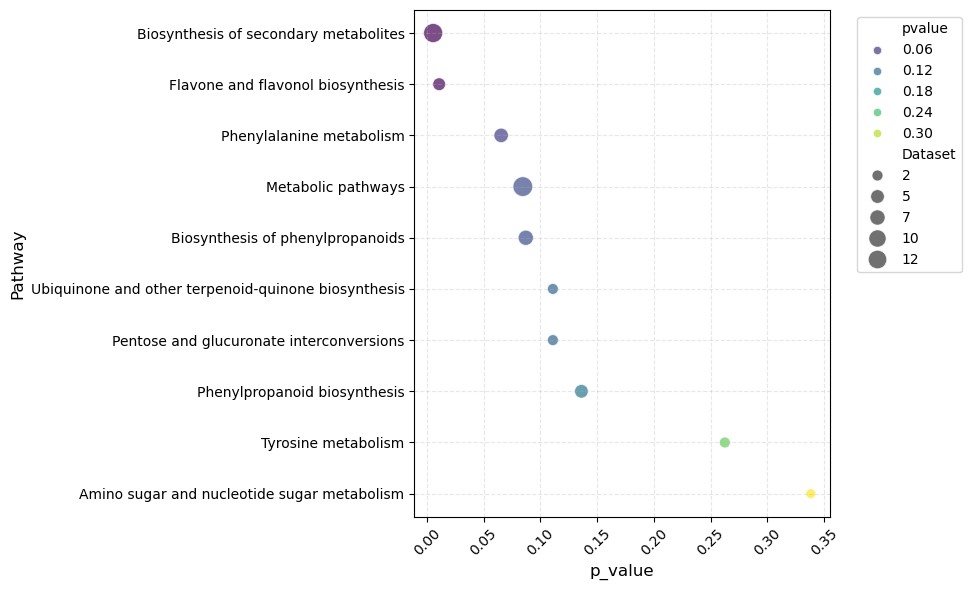

In [73]:
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_excel("C:/Users/tamer/Documents/PhD/KEGG/KEGG_LP_SP_lemon.xlsx")

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="pvalue",
    y="Map Name",
    size="Dataset",
    hue="pvalue",
    sizes=(50, 200),
    palette="viridis",
    alpha=0.7
)

plt.xlabel('p_value', fontsize = 12)
plt.ylabel('Pathway', fontsize = 12)
plt.grid(True, which='both', linestyle='--', alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.savefig("C:/Users/tamer/Documents/PhD/KEGG/KEGG_LP_SP_lemon.png", dpi=600, bbox_inches="tight")  

plt.show()

